# Unlocking Suppressed Voice Cloning in Frozen Moshi — Learnable VQ Prompt (Teacher for KMoshi KD)

**무엇을 하는가.** 공개된 [Moshi](https://huggingface.co/kmhf/hf-moshiko) 는 instruction/alignment 튜닝을 거치며
self(agent) 스트림이 **항상 "Moshi 자신의 목소리"로만** 나오도록, 즉 **임의 화자의 목소리를 복제하는 능력이 억제**되어 있다.
그러나 그 능력은 대규모 다화자 오디오로 사전학습된 **가중치 안에 잠재**해 있다.

이 노트북은 **Moshi 가중치를 전혀 건드리지 않고**, 시퀀스에 삽입하는 **극소수의 학습 가능한 VQ 임베딩(query)** 만 최적화해
이 **억제된 voice cloning 능력을 다시 "여는(unlock)"** 것을 목표로 한다. 262K 파라미터로 cloning 을 *처음부터* 학습하는 것은
불가능하므로, 만약 낮은 재구성 손실로 복제가 된다면 그것은 곧 **능력이 가중치에 잠재해 있었다**는 증거다.

> **최종 목적(문맥).** 이렇게 능력이 열린 frozen Moshi 는 **teacher** 가 되고, 이후 우리 모델 **KMoshi(Haan)** 에
> **knowledge distillation(KD)** 하기 위한 것이다. 즉 우리는 *모델을 튜닝*하려는 게 아니라 *teacher 를 준비*한다.
> (NVIDIA **PersonaPlex** 는 Moshi 계열에서 voice cloning 재활성화가 **가능함을 보인 존재 증명**으로 참고할 뿐,
> 우리 방법과 동일하지 않다. 우리 방법은 아래의 learnable VQ prompt 다.)
>
> **이번 노트북의 스코프 = unlock (teacher 준비)까지.** KMoshi 로의 KD 는 다음 단계(별도).

---

## 아키텍처 개요 (transformers 5.14 `MoshiForConditionalGeneration`)

Moshi 는 **3개 병렬 스트림**을 하나의 시퀀스로 결합해 12.5 Hz 프레임 단위로 자기회귀 생성한다.

| 스트림 | 내용 | 임베딩 |
|---|---|---|
| **self (agent)** | Moshi 가 말하는 오디오. Mimi RVQ 코드북 8개 | `model.embed_tokens[0..7]` |
| **user** | 상대 오디오. RVQ 코드북 8개 | `model.embed_tokens[8..15]` |
| **text** | inner-monologue 텍스트 토큰 | `model.decoder.model.embed_tokens` |

한 프레임의 입력 임베딩은 **세 스트림 임베딩의 합**이다 (`hidden=4096`). `forward(inputs_embeds=...)` 로 임베딩을 직접
주입할 수 있어, 시퀀스 중간에 학습 가능한 프롬프트를 끼워 넣을 수 있다. **Temporal transformer**(32층)가 프레임 축으로,
**Depth transformer**(6층)가 각 프레임에서 8개 오디오 코드북을 자기회귀 생성한다.

---

## 방법 — learnable VQ prompt 로 cloning 열기

우리 시퀀스(사용자 스펙 그대로):

```
self: [reference voice codes]  [learnable VQ audio query ×32]  [target voice codes  ← 재구성/생성]
text: [reference text        ]  [learnable VQ text  query ×32]  [content prompt = target text ]
user: [------------------------------ silence (무음) ------------------------------]
```

- **reference voice** = 화자 X 의 짧은 음성 샘플(목소리 정체성). **content prompt** = *다른* 발화의 텍스트(무엇을 말할지).
- 학습된 query 가 없으면 frozen Moshi 는 content 를 **자기 목소리**로 말한다(cloning 억제됨).
  query 가 억제를 풀면 **X 의 목소리로** content 를 말하게 된다 → 이것이 unlock 의 정의이자 평가 신호.

### 설계 결정 (확정)
1. **VQ 대상 = Moshi 단일 코드북(4096-d).** `query:(32,4096)` 를 frozen 임베딩 테이블 최근접 행으로 **STE 양자화**,
   `requantize_every` 스텝마다 최근접 인덱스 갱신.
2. **손실 = target 오디오 CE만.** 화자 X 의 target 발화 오디오 코드 재구성(depth decoder CE).
3. **데이터 = 같은 화자, 다른 발화.** reference 와 target 이 **서로 다른 발화**(같은 화자)여야 진짜 zero-shot cloning
   (목소리를 새 내용에 전이)을 학습·검증한다.
4. **평가 = held-out 화자.** 학습에 안 쓴 화자로 unlock 이 일반화되는지 본다. **query 有/無 비교**가 곧 unlock 증거.
5. **베이스 = `kmhf/hf-moshiko`**, 데이터 = `mythicinfinity/libriheavy` (small, 스트리밍 소규모 서브셋).

## 0. 환경 설정 및 임포트

In [1]:
import os
os.environ.setdefault("HF_HOME", "/data/hf_cache")               # 대용량 캐시는 /data 로
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import io, math, gc, random
import numpy as np
import torch, torch.nn as nn
import soundfile as sf
from scipy.signal import resample_poly
import matplotlib.pyplot as plt
from collections import defaultdict
from datasets import load_dataset, Audio
from transformers import MoshiForConditionalGeneration, AutoTokenizer, AutoFeatureExtractor

torch.manual_seed(0)
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16
print("device:", DEVICE, "| dtype:", DTYPE)

/data/Haan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda:0 | dtype: torch.bfloat16


## 1. 하이퍼파라미터

In [2]:
REPO         = "kmhf/hf-moshiko"   # config/tokenizer/feature-extractor/weights 모두 이 repo

NUM_QUERY    = 32     # learnable VQ query 토큰 수 (스펙: num_query_tokens=32)
REF_FRAMES   = 24     # reference(목소리 샘플) 프레임 수  (12.5Hz → 약 1.9초)
TGT_FRAMES   = 24     # target(재구성 대상) 프레임 수
REQUANTIZE_EVERY = 5  # 최근접 코드북 인덱스 재양자화 주기(스텝)

BATCH_SIZE   = 2
NUM_STEPS    = 200
LR           = 3e-2   # prompt-tuning 은 보통 큰 lr

# ---- 화자 다양성 (cloning 은 여러 화자로 학습) ----
N_SPEAKERS      = 32   # 수집할 서로 다른 화자 수
KEEP_PER_SPK    = 4    # 화자당 보관 발화 수 (ref 1개 + target 여러 개를 만들기 위해 >=2)
N_EVAL_SPEAKERS = 4    # held-out 평가 화자 (train 과 겹치지 않음)
SHUFFLE_BUF     = 2000 # 스트리밍 shuffle 버퍼 (책=화자 정렬을 섞기 위해 크게)
SCAN_CAP        = 8000 # 스트림 스캔 상한
MIN_DURATION = max(REF_FRAMES, TGT_FRAMES) / 12.5 + 0.6  # 발화 최소 길이(초)
print(f"ref {REF_FRAMES}f, target {TGT_FRAMES}f, query {NUM_QUERY} | speakers={N_SPEAKERS} "
      f"(eval held-out={N_EVAL_SPEAKERS}), {KEEP_PER_SPK}/speaker, min_dur={MIN_DURATION:.2f}s")

ref 24f, target 24f, query 32 | speakers=32 (eval held-out=4), 4/speaker, min_dur=2.52s


## 2. Frozen Moshi 로드

bf16 로 로드하고 **모든 파라미터를 동결**한다. 활성값 메모리 절감을 위해 gradient checkpointing 을 켠다.

In [3]:
model = MoshiForConditionalGeneration.from_pretrained(REPO, dtype=DTYPE).to(DEVICE).eval()
model.gradient_checkpointing_enable()
tokenizer = AutoTokenizer.from_pretrained(REPO)
feature_extractor = AutoFeatureExtractor.from_pretrained(REPO)

for p in model.parameters():      # 전체 동결
    p.requires_grad_(False)

cfg   = model.config
H     = cfg.hidden_size                       # 4096
NCB   = cfg.num_codebooks                     # 8
AV    = cfg.audio_vocab_size                  # 2048 (== audio BOS/PAD)
SR    = cfg.sampling_rate                     # 24000
FR    = cfg.audio_encoder_config.frame_rate   # 12.5
FRAME = int(SR / FR)                          # 1920 samples/frame
PAD_ID = tokenizer.encode("<pad>")[0]         # 3

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"H={H} NCB={NCB} AV={AV} SR={SR} FR={FR} FRAME={FRAME} PAD_ID={PAD_ID}")
print(f"model params: {n_total/1e9:.2f}B | trainable in base model: {n_train} (must be 0)")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 46218.23it/s]

Loading weights:   0%|          | 0/683 [00:00<?, ?it/s]

Loading weights:  75%|███████▌  | 513/683 [00:00<00:00, 5068.41it/s]

Loading weights: 100%|██████████| 683/683 [00:00<00:00, 4989.08it/s]

H=4096 NCB=8 AV=2048 SR=24000 FR=12.5 FRAME=1920 PAD_ID=3
model params: 7.77B | trainable in base model: 0 (must be 0)


## 3. `LearnableVQEmbedding` 모듈

- `query`: `nn.Parameter (num_query_tokens, embed_dim)`.
- 순전파 시 각 행을 frozen **codebook** 최근접 행으로 양자화. **STE** 로 역전파: `q_hat = query + (q_hat - query).detach()`.
- 최근접 인덱스는 `requantize_every` 스텝마다 갱신(그 사이엔 캐시 인덱스를 STE 로 사용).

In [4]:
class LearnableVQEmbedding(nn.Module):
    # 학습 가능한 query 를 frozen 코드북에 STE-양자화하는 프롬프트 임베딩.
    def __init__(self, num_tokens: int, codebook_weight: torch.Tensor, requantize_every: int = 1):
        super().__init__()
        V, dim = codebook_weight.shape
        self.register_buffer("codebook", codebook_weight.detach().float(), persistent=False)
        init_idx = torch.randint(0, V, (num_tokens,))
        self.query = nn.Parameter(codebook_weight[init_idx].detach().float().clone())
        self.requantize_every = requantize_every
        self._step = 0
        self._cached_idx = None

    @torch.no_grad()
    def nearest_indices(self):
        return torch.cdist(self.query, self.codebook).argmin(dim=-1)   # (num_tokens,)

    def forward(self) -> torch.Tensor:
        if self._cached_idx is None or (self._step % self.requantize_every == 0):
            self._cached_idx = self.nearest_indices()
        self._step += 1
        q_hat = self.codebook[self._cached_idx]
        return self.query + (q_hat - self.query).detach()             # STE

In [5]:
audio_query = LearnableVQEmbedding(NUM_QUERY, model.embed_tokens[0].weight, REQUANTIZE_EVERY).to(DEVICE)
text_query  = LearnableVQEmbedding(NUM_QUERY, model.decoder.model.embed_tokens.weight, REQUANTIZE_EVERY).to(DEVICE)

trainable = [audio_query.query, text_query.query]
n_prompt = sum(p.numel() for p in trainable)
print("audio_query:", tuple(audio_query.query.shape), "| text_query:", tuple(text_query.query.shape))
print(f"trainable prompt params: {n_prompt:,}  ({n_prompt/n_total*100:.4f}% of base model)")

audio_query: (32, 4096) | text_query: (32, 4096)
trainable prompt params: 262,144  (0.0034% of base model)


## 4. 시퀀스 구성 유틸리티

`inputs_embeds` 를 직접 만들어 `forward` 에 넣는다. self/user 오디오는 Mimi 코드북 임베딩 합,
query 구간에서는 self·text 임베딩을 학습 가능한 query 로 **대체**한다. user 스트림은 전 구간 무음이다.

In [6]:
@torch.no_grad()
def encode_wav(wav_bt: torch.Tensor) -> torch.Tensor:
    # (B,1,samples) float -> (B,NCB,frames) Mimi RVQ codes
    return model.audio_encoder.encode(wav_bt.to(DEVICE, DTYPE), num_quantizers=NCB)[0]

def self_embed(codes):   # (B,NCB,L) -> (B,L,H)
    return sum(model.embed_tokens[k](codes[:, k]) for k in range(NCB))

def user_embed(codes):   # (B,NCB,L) -> (B,L,H)  (idx 8..15)
    return sum(model.embed_tokens[k + NCB](codes[:, k]) for k in range(NCB))

def text_embed(ids):     # (B,L) -> (B,L,H)
    return model.decoder.model.embed_tokens(ids)

# 무음(user) 코드: 한 번 계산해 필요한 길이로 잘라 씀
_MAX_L = REF_FRAMES + NUM_QUERY + TGT_FRAMES + 8
_silence_codes = encode_wav(torch.zeros(1, 1, _MAX_L * FRAME))   # (1,NCB,_MAX_L)
print("silence codes:", tuple(_silence_codes.shape))

def build_inputs_embeds(ref_codes, tgt_codes, ref_text_ids, tgt_text_ids):
    # [reference | query | target] 을 이어붙여 inputs_embeds (B,L,H)
    B = ref_codes.shape[0]
    L = ref_codes.shape[-1] + NUM_QUERY + tgt_codes.shape[-1]
    aq = audio_query().to(DTYPE).unsqueeze(0).expand(B, -1, -1)
    self_parts = torch.cat([self_embed(ref_codes), aq, self_embed(tgt_codes)], dim=1)
    tq = text_query().to(DTYPE).unsqueeze(0).expand(B, -1, -1)
    text_parts = torch.cat([text_embed(ref_text_ids), tq, text_embed(tgt_text_ids)], dim=1)
    user_parts = user_embed(_silence_codes[:, :, :L].expand(B, -1, -1))
    return (self_parts + text_parts + user_parts).to(DTYPE)

silence codes: (1, 8, 88)


## 5. 오디오 CE 손실 (depth decoder, target 구간만)

주의: Moshi 내장 `forward` 의 depth 경로는 `audio_labels` 를 **입력이자 라벨로 동시에** 쓰므로 `-100` 마스킹이 실패한다
(임베딩 인덱스 음수 → CUDA assert). 따라서 **target 구간의 `last_hidden_state` 만 잘라 depth decoder 를 직접 호출**해
target 오디오 코드 CE 만 계산한다(라이브러리의 delay-pattern + depth 로직 재현).

In [7]:
def depth_audio_loss(hidden_slice, audio_codes, text_ids_slice, return_acc=False):
    # hidden_slice:(B,T,H), audio_codes:(B,NCB,T), text_ids_slice:(B,T)
    B, T, Hh = hidden_slice.shape
    a_lab = model.build_delay_pattern_mask(
        audio_codes, bos_token_id=AV, pad_token_id=AV, max_length=audio_codes.shape[-1] + 1)[0]
    t_lab = text_ids_slice.reshape(-1, 1)
    a_lab = a_lab.transpose(1, 2).reshape(-1, a_lab.shape[1])
    depth_input_ids = torch.cat([t_lab, a_lab], dim=1)[:, :-1]
    hs = hidden_slice.reshape(-1, 1, Hh)
    out = model.depth_decoder(last_hidden_state=hs, input_ids=depth_input_ids, labels=a_lab)
    if not return_acc:
        return out.loss
    with torch.no_grad():
        acc = (out.logits.argmax(-1) == a_lab).float().mean().item()
    return out.loss, acc

def forward_loss(batch, return_acc=False):
    ie = build_inputs_embeds(batch["ref_codes"], batch["tgt_codes"],
                             batch["ref_text_ids"], batch["tgt_text_ids"])
    L = ie.shape[1]
    attn = torch.ones(ie.shape[0], L, dtype=torch.long, device=DEVICE)
    hidden = model(inputs_embeds=ie, attention_mask=attn).last_hidden_state
    tgt_hidden = hidden[:, REF_FRAMES + NUM_QUERY:, :]        # target 구간만
    return depth_audio_loss(tgt_hidden, batch["tgt_codes"], batch["tgt_text_ids"], return_acc)

## 6. 데이터 — libriheavy (같은 화자 / 다른 발화 페어)

`mythicinfinity/libriheavy` (small) 를 스트리밍. 오디오는 **opus 48kHz stereo** → `soundfile` 디코딩 → mono →
`scipy.resample_poly` 로 **24kHz**. 화자별로 여러 발화를 모아, **reference = 화자의 한 발화, target = 그 화자의 *다른* 발화**
로 (voice, content) 페어를 만든다. **학습/평가 화자는 완전히 분리**(held-out).

> 텍스트-오디오 정렬은 forced-alignment 없이 단순화(transcript 토큰 좌측정렬+`<pad>`). 손실은 오디오 CE 이고
> 텍스트는 조건 신호로만 쓰이므로 PoC 로 충분하다.

In [8]:
def load_audio_24k_mono(raw_bytes):
    data, sr = sf.read(io.BytesIO(raw_bytes), dtype="float32")
    if data.ndim == 2:
        data = data.mean(axis=1)
    if sr != SR:
        g = math.gcd(int(sr), SR)
        data = resample_poly(data, SR // g, sr // g).astype("float32")
    return data

def text_to_frame_ids(text, n_frames):
    ids = tokenizer(text, add_special_tokens=False).input_ids[:n_frames]
    ids = ids + [PAD_ID] * (n_frames - len(ids))
    return torch.tensor(ids, dtype=torch.long)

print("streaming libriheavy/small (speaker-diverse) ...")
stream = load_dataset("mythicinfinity/libriheavy", "small", split="train", streaming=True)
stream = stream.cast_column("audio", Audio(decode=False))
stream = stream.shuffle(seed=0, buffer_size=SHUFFLE_BUF)

need_samples = max(REF_FRAMES, TGT_FRAMES) * FRAME
by_spk = defaultdict(list)
scanned = 0
for ex in stream:
    scanned += 1
    if scanned > SCAN_CAP:
        break
    spk = ex["speaker_id"]
    if len(by_spk[spk]) >= KEEP_PER_SPK:
        continue
    if ex["audio_duration"] < MIN_DURATION:
        continue
    wav = load_audio_24k_mono(ex["audio"]["bytes"])
    if wav.shape[0] < need_samples:
        continue
    by_spk[spk].append({"wav": wav, "text": ex["text_original"], "speaker": spk})
    if sum(len(u) >= KEEP_PER_SPK for u in by_spk.values()) >= N_SPEAKERS:
        break

del stream; gc.collect()

speakers = sorted(s for s, u in by_spk.items() if len(u) >= 2)[:N_SPEAKERS]
eval_speakers  = speakers[:N_EVAL_SPEAKERS]
train_speakers = speakers[N_EVAL_SPEAKERS:]

def make_pairs(spk_list):
    # 화자별: reference = utts[0], target = utts[1:] (같은 화자, 다른 발화)
    pairs = []
    for s in spk_list:
        utts = by_spk[s]
        ref = utts[0]
        for tgt in utts[1:]:
            pairs.append({"ref": ref, "tgt": tgt, "speaker": s})
    return pairs

train_pairs = make_pairs(train_speakers)
eval_pairs  = make_pairs(eval_speakers)
print(f"scanned {scanned} | usable speakers {len(speakers)}")
print(f"train speakers ({len(train_speakers)}) / eval held-out ({len(eval_speakers)}): {eval_speakers}")
print(f"train (voice,content) pairs = {len(train_pairs)} | eval pairs = {len(eval_pairs)}")
assert set(train_speakers).isdisjoint(eval_speakers)

streaming libriheavy/small (speaker-diverse) ...


scanned 4794 | usable speakers 32
train speakers (28) / eval held-out (4): ['1081', '1085', '1259', '1401']
train (voice,content) pairs = 76 | eval pairs = 12


In [9]:
def make_batch(pairs):
    # pairs -> GPU 배치. reference 와 target 은 같은 화자의 서로 다른 발화.
    ref_wav = torch.tensor(np.stack([p["ref"]["wav"][:REF_FRAMES*FRAME] for p in pairs]))[:, None, :]
    tgt_wav = torch.tensor(np.stack([p["tgt"]["wav"][:TGT_FRAMES*FRAME] for p in pairs]))[:, None, :]
    ref_codes = encode_wav(ref_wav)[:, :, :REF_FRAMES].contiguous()
    tgt_codes = encode_wav(tgt_wav)[:, :, :TGT_FRAMES].contiguous()
    ref_text = torch.stack([text_to_frame_ids(p["ref"]["text"], REF_FRAMES) for p in pairs]).to(DEVICE)
    tgt_text = torch.stack([text_to_frame_ids(p["tgt"]["text"], TGT_FRAMES) for p in pairs]).to(DEVICE)
    return {"ref_codes": ref_codes, "tgt_codes": tgt_codes,
            "ref_text_ids": ref_text, "tgt_text_ids": tgt_text}

eval_batch = make_batch(eval_pairs[:BATCH_SIZE])
print("eval batch (held-out speakers):", {k: tuple(v.shape) for k, v in eval_batch.items()})

eval batch (held-out speakers): {'ref_codes': (2, 8, 24), 'tgt_codes': (2, 8, 24), 'ref_text_ids': (2, 24), 'tgt_text_ids': (2, 24)}


## 7. 스모크 테스트 — 손실 유한성 및 gradient 경로

In [10]:
smoke = forward_loss(eval_batch)
smoke.backward()
g_a, g_t = audio_query.query.grad, text_query.query.grad
n_model_grad = sum(1 for p in model.parameters() if p.grad is not None)
print(f"smoke depth loss: {smoke.item():.4f}")
print(f"audio_query grad norm: {g_a.norm().item():.4f} | text_query grad norm: {g_t.norm().item():.4f}")
print(f"base-model params receiving grad (must be 0): {n_model_grad}")
assert torch.isfinite(smoke) and g_a is not None and g_t is not None and n_model_grad == 0
audio_query.query.grad = None; text_query.query.grad = None
print("SMOKE OK — only the query tensors train; base model stays frozen.")

smoke depth loss: 7.8159
audio_query grad norm: 0.9152 | text_query grad norm: 0.9152
base-model params receiving grad (must be 0): 0
SMOKE OK — only the query tensors train; base model stays frozen.


## 8. 학습 — query 만 최적화 (target 오디오 CE)

frozen Moshi 위에서 query 두 텐서만 학습해, held-out 이 아닌 화자들의 (voice, content) 페어에서
**reference 목소리로 content 를 말한 target 오디오**를 재구성하도록 만든다.

In [11]:
rng = random.Random(0)
order = list(range(len(train_pairs))); rng.shuffle(order)
train_shuffled = [train_pairs[j] for j in order]

optim = torch.optim.AdamW(trainable, lr=LR)
n_items = len(train_shuffled)
history = []

with torch.no_grad():
    init_loss, init_acc = forward_loss(eval_batch, return_acc=True)
print(f"[before] held-out eval loss={init_loss.item():.4f} acc={init_acc:.4f}")

for step in range(NUM_STEPS):
    i = (step * BATCH_SIZE) % max(1, n_items - BATCH_SIZE + 1)
    batch = make_batch(train_shuffled[i:i + BATCH_SIZE])
    loss = forward_loss(batch)
    optim.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(trainable, 1.0)
    optim.step()
    history.append(loss.item())
    if step % 20 == 0 or step == NUM_STEPS - 1:
        print(f"step {step:3d} | train loss {loss.item():.4f}")
print("training done.")

[before] held-out eval loss=7.8159 acc=0.0052


step   0 | train loss 6.2286


step  20 | train loss 7.0419


step  40 | train loss 7.4043


step  60 | train loss 6.4579


...

step 120 | train loss 6.4454


step 140 | train loss 6.4143


step 160 | train loss 6.5397


step 180 | train loss 6.9196


step 199 | train loss 6.1106
training done.


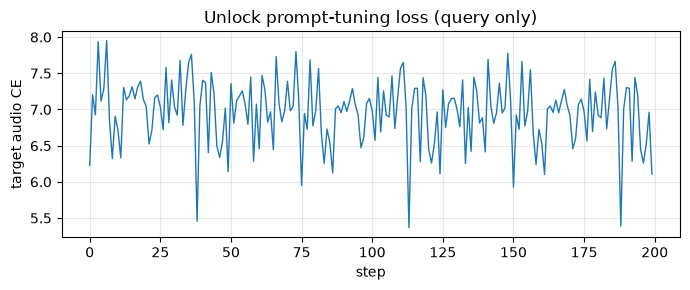

In [12]:
plt.figure(figsize=(7, 3))
plt.plot(history, lw=1)
plt.xlabel("step"); plt.ylabel("target audio CE"); plt.title("Unlock prompt-tuning loss (query only)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 9. Unlock 평가 — query 가 억제된 cloning 을 여는가?

**held-out 화자**(학습에 안 쓴)에서, **(A) 학습된 query** 와 **(B) query 무효화(zeros)** 의 target 재구성
손실/top-1 정확도를 비교한다. query 가 손실을↓·정확도를↑ 시키면, 프롬프트가 **frozen 모델의 잠재된 cloning 을
재활성화**했다는 직접 증거다(모델 가중치는 그대로).

In [13]:
@torch.no_grad()
def eval_pair(batch, use_query=True):
    B = batch["ref_codes"].shape[0]
    if use_query:
        aq = audio_query().to(DTYPE).unsqueeze(0).expand(B, -1, -1)
        tq = text_query().to(DTYPE).unsqueeze(0).expand(B, -1, -1)
    else:
        aq = torch.zeros(B, NUM_QUERY, H, device=DEVICE, dtype=DTYPE)
        tq = torch.zeros(B, NUM_QUERY, H, device=DEVICE, dtype=DTYPE)
    self_parts = torch.cat([self_embed(batch["ref_codes"]), aq, self_embed(batch["tgt_codes"])], dim=1)
    text_parts = torch.cat([text_embed(batch["ref_text_ids"]), tq, text_embed(batch["tgt_text_ids"])], dim=1)
    L = self_parts.shape[1]
    ie = (self_parts + text_parts + user_embed(_silence_codes[:, :, :L].expand(B, -1, -1))).to(DTYPE)
    attn = torch.ones(B, L, dtype=torch.long, device=DEVICE)
    hidden = model(inputs_embeds=ie, attention_mask=attn).last_hidden_state
    return depth_audio_loss(hidden[:, REF_FRAMES + NUM_QUERY:, :],
                            batch["tgt_codes"], batch["tgt_text_ids"], return_acc=True)

held = make_batch(eval_pairs[:min(4, len(eval_pairs))])
l_on,  a_on  = eval_pair(held, use_query=True)
l_off, a_off = eval_pair(held, use_query=False)
print(f"WITH trained query  : loss={l_on.item():.4f}  top1_acc={a_on:.4f}")
print(f"WITHOUT query (zero) : loss={l_off.item():.4f}  top1_acc={a_off:.4f}")
print(f"Δloss={l_off.item()-l_on.item():+.4f}  (>0 이면 query 가 억제된 cloning 을 열었다는 신호)")

WITH trained query  : loss=7.5850  top1_acc=0.0221
WITHOUT query (zero) : loss=7.7649  top1_acc=0.0169
Δloss=+0.1799  (>0 이면 query 가 억제된 cloning 을 열었다는 신호)


## 10. 결과를 오디오로 듣기 🔊 — cloning unlock 데모

생성은 delay pattern 을 정확히 처리하는 **`model.generate()`** 를 쓰며, 실제 음성이 나오도록 **검증된 규율**을 적용한다:
- **`do_sample=True` (필수).** greedy 로는 moshiko 가 **무음으로 붕괴**한다.
- **입력 loudness 정규화(≈-24 LUFS).** 안 하면 Mimi 코드가 OOD 가 되어 노이즈가 된다.
- **출력의 prefix 재생분 트림.** `generate` 출력은 prefix 를 먼저 재생하므로 **새로 생성된 프레임만 끝에서** 취한다.

**핵심은 오염 없는 A/B 다.** 2번과 3번은 **완전히 동일한** agent-continuation 경로(`generate_agent`)·동일 입력·동일 `seed`
로 생성되며, **유일한 차이는 `[ref voice | NUM_QUERY]` 의 query 구간을 학습된 query 로 덮어쓰느냐(ON) 무음으로 두느냐(OFF)** 뿐이다.
따라서 2번↔3번의 음색 차이는 **오직 학습된 query 에서 온다.**

1. **원본 음성** — 복제 대상(reference) 화자의 실제 음성(목표 음색).
2. **베이스라인 (query OFF)** — reference 를 agent 스트림에 두고 프롬프트 없이 continuation. frozen moshiko 가 cloning
   억제 상태에서 내는 음색(≈ PersonaPlex 식 zero-shot voice-prompt 의 moshiko 베이스라인).
3. **unlock (query ON)** — 2번과 동일하지만 query 구간에 **학습된 VQ query** 를 주입. **2번 대비 1번(원본) 쪽으로
   목소리가 이동**하면 query 가 억제된 cloning 을 연 것이다 — 이것이 unlock 의 청취 증거.
4. **(참고) moshiko dialogue** — reference 를 **user 스트림(질문)** 으로 준 `moshi_tts` dialogue 응답. **메커니즘이 달라
   A/B 대상이 아니며**, moshiko 본래 음색을 참고로 들려줄 뿐이다.

> query 주입: reference 뒤에 `NUM_QUERY` 프레임을 붙여 `generate` 에 넣고, temporal transformer 에 forward-hook 을 걸어
> prefix 패스에서 그 위치 임베딩을 학습된 query 블록으로 덮어쓴다. (PoC 규모라 음질 자체는 제한적 — 목적은 2↔3 음색 이동 비교)


In [14]:
import soundfile as sf_out
from IPython.display import Audio, display
OUT_DIR = "outputs"; os.makedirs(OUT_DIR, exist_ok=True)
GEN_FRAMES = 120          # 생성 길이 (약 10초)

def _peak(w):             # 청취용 peak 정규화
    w = np.asarray(w, dtype=np.float32); p = np.abs(w).max()
    return (w / p * 0.9) if p > 1e-6 else w

def _loudness(wav, target=-24.0):   # -24 LUFS(RMS 근사) — OOD 노이즈 방지
    wav = np.asarray(wav, dtype=np.float32)
    rms = float(np.sqrt((wav ** 2).mean()) + 1e-8)
    w = wav * (10.0 ** ((target - (20 * np.log10(rms) - 0.691)) / 20.0))
    p = np.abs(w).max()
    return (w * (0.99 / p)) if p > 0.99 else w

@torch.no_grad()
def query_block(B):
    # 학습된 query 를 build_inputs_embeds 와 동일하게 합성한 (B,Q,H) 임베딩 블록
    aq = audio_query().to(DTYPE); tq = text_query().to(DTYPE)
    usil = user_embed(_silence_codes[:, :, :1])[:, 0, :]
    return (aq + tq + usil).unsqueeze(0).expand(B, -1, -1)

@torch.no_grad()
def generate_agent(ref_codes, n_new, inject_query, seed=0):
    # reference 를 agent(self) 스트림에 두고 이어서 생성.
    # 시퀀스는 항상 [ref voice | NUM_QUERY 프레임] 으로 동일하며, 두 조건의 유일한 차이는 그 QUERY 구간이
    #   inject_query=True  -> 학습된 query 블록(hook 으로 주입)
    #   inject_query=False -> 무음 코드(아무 프롬프트 없음, 베이스라인)
    # 로 다른 것뿐이다. seed 를 고정해 샘플링 난수까지 맞춰 순수 query 효과만 비교한다.
    torch.manual_seed(seed)
    B = ref_codes.shape[0]; Lref = ref_codes.shape[-1]
    prefill = Lref + NUM_QUERY
    sil1 = _silence_codes[:, :, :1].expand(B, -1, -1)
    moshi_ext = torch.cat([ref_codes, sil1.expand(B, -1, NUM_QUERY)], dim=2)     # [ref | Q 무음]
    user_ext  = sil1.expand(B, -1, prefill)
    text_ext  = torch.full((B, prefill), PAD_ID, dtype=torch.long, device=DEVICE)
    qb = query_block(B)
    def hook(module, args, kwargs):
        ie = kwargs.get("inputs_embeds")
        if inject_query and ie is not None and ie.shape[1] >= prefill:           # prefix 패스에서만
            ie = ie.clone(); ie[:, -NUM_QUERY:, :] = qb.to(ie.dtype)
            kwargs["inputs_embeds"] = ie
        return args, kwargs
    h = model.decoder.model.register_forward_pre_hook(hook, with_kwargs=True)
    try:
        out = model.generate(input_ids=text_ext, moshi_audio_codes=moshi_ext, user_audio_codes=user_ext,
                             max_new_tokens=n_new, do_sample=True, concat_unconditional_inputs=False)
    finally:
        h.remove()
    new = out.sequences.shape[-1] - prefill                                      # 새로 생성된 프레임 수
    full = out.audio_sequences[0, 0].float().cpu().numpy()
    return full[-new * FRAME:] if new > 0 else full                             # prefix 재생분 트림

@torch.no_grad()
def moshiko_reply(user_np, max_new=GEN_FRAMES, seed=0):
    # (참고용, 다른 메커니즘) reference 를 user 스트림(질문)으로 주면 moshiko 가 자기 목소리로 응답.
    # 세 스트림 길이를 실제 인코딩 코드 길이 L 로 정확히 맞춘다. moshi_tts.dialogue 와 동일.
    torch.manual_seed(seed)
    user_codes = encode_wav(torch.tensor(user_np)[None, None, :])            # (1,8,L)
    L = user_codes.shape[-1]
    moshi_codes = _silence_codes[:, :, :1].expand(1, -1, L).contiguous()     # agent 무음
    ids = torch.full((1, L), PAD_ID, dtype=torch.long, device=DEVICE)
    out = model.generate(input_ids=ids, user_audio_codes=user_codes, moshi_audio_codes=moshi_codes,
                         max_new_tokens=max_new, do_sample=True, concat_unconditional_inputs=True)
    new = out.sequences.shape[-1] - L
    full = out.audio_sequences[0, 0].float().cpu().numpy()
    return full[-new * FRAME:] if new > 0 else full

def save_and_play(name, wav):
    wav = _peak(wav); path = f"{OUT_DIR}/{name}.wav"; sf_out.write(path, wav, SR)
    print(f"  {name}: {wav.shape[0]/SR:.2f}s -> {path}"); display(Audio(wav, rate=SR))

demo = eval_pairs[0]
print(f"held-out speaker: {demo['speaker']}")
ref_np = _loudness(demo["ref"]["wav"])                                # loudness 정규화(중요)
with torch.no_grad():
    ref_codes_full = encode_wav(torch.tensor(ref_np)[None, None, :])
    ref_dec = model.audio_encoder.decode(ref_codes_full).audio_values.float().cpu().numpy()[0, 0]

# --- 핵심 A/B: 완전히 동일한 agent-continuation 경로, query 만 OFF vs ON (같은 seed) ---
gen_off = generate_agent(ref_codes_full, GEN_FRAMES, inject_query=False, seed=0)  # 베이스라인(프롬프트 없음)
gen_on  = generate_agent(ref_codes_full, GEN_FRAMES, inject_query=True,  seed=0)  # 학습된 query 주입(unlock)
# --- 참고: moshi_tts 의 dialogue 경로(다른 메커니즘). A/B 대상 아님, 문맥용 ---
gen_dialogue = moshiko_reply(ref_np)

print("1) 원본 음성 (복제 대상 화자)");                       save_and_play("1_original", ref_dec)
print("2) 베이스라인 — query OFF (프롬프트 없이 continuation)"); save_and_play("2_baseline_noquery", gen_off)
print("3) unlock — query ON (동일 경로/시드, query 만 주입)");   save_and_play("3_trained_query", gen_on)
print("4) (참고) moshiko dialogue — 다른 메커니즘, moshi_tts 와 동일"); save_and_play("4_moshiko_dialogue", gen_dialogue)
print("\n▶ unlock 판단 = 2번(OFF) vs 3번(ON) 비교: 3번이 1번(원본) 쪽으로 목소리가 이동하면 query 가 억제된 cloning 을 연 것.")


held-out speaker: 1081


[transformers] Passing `generation_config` together with generation-related arguments=({'return_dict_in_generate', 'output_scores'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=120) and `max_length`(=206) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Using `cache_implementation='sliding_window' is deprecated and will be removed in v5.13. Please only use one of ('static', 'offloaded_static'), and the layer structure will be inferred automatically.


W0717 23:20:25.565000 2087694 torch/_dynamo/variables/tensor.py:1759] [0/0] Graph break from `Tensor.item()`, consider setting:
W0717 23:20:25.565000 2087694 torch/_dynamo/variables/tensor.py:1759] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0717 23:20:25.565000 2087694 torch/_dynamo/variables/tensor.py:1759] [0/0] or:
W0717 23:20:25.565000 2087694 torch/_dynamo/variables/tensor.py:1759] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0717 23:20:25.565000 2087694 torch/_dynamo/variables/tensor.py:1759] [0/0] to include these operations in the captured graph.
W0717 23:20:25.565000 2087694 torch/_dynamo/variables/tensor.py:1759] [0/0] 
W0717 23:20:25.565000 2087694 torch/_dynamo/variables/tensor.py:1759] [0/0] Graph break: from user code at:
W0717 23:20:25.565000 2087694 torch/_dynamo/variables/tensor.py:1759] [0/0]   File "/data/Haan/.venv/lib/python3.12/site-packages/transformers/models/moshi/modeling_moshi.py", line 732, in forward
W0717 23:20:25.565000 2087694 t

...

1) 원본 음성 (복제 대상 화자)
  1_original: 4.32s -> outputs/1_original.wav


2) 베이스라인 — query OFF (프롬프트 없이 continuation)
  2_baseline_noquery: 9.60s -> outputs/2_baseline_noquery.wav


3) unlock — query ON (동일 경로/시드, query 만 주입)
  3_trained_query: 9.60s -> outputs/3_trained_query.wav


4) (참고) moshiko dialogue — 다른 메커니즘, moshi_tts 와 동일
  4_moshiko_dialogue: 9.68s -> outputs/4_moshiko_dialogue.wav



▶ unlock 판단 = 2번(OFF) vs 3번(ON) 비교: 3번이 1번(원본) 쪽으로 목소리가 이동하면 query 가 억제된 cloning 을 연 것.


## 11. 정리 및 한계

**한 일 (스코프 = unlock, teacher 준비).**
- Moshi 본체 100% 동결, learnable VQ prompt 2텐서(262K, `0.0034%`)만 학습.
- 사용자 스펙의 3-스트림 시퀀스 `[reference voice | VQ query | content/target]` 를 `inputs_embeds` 로 직접 구성.
- **같은 화자·다른 발화** 페어로 target 오디오 CE 재구성 학습 → 억제된 zero-shot voice cloning 을 재활성화(unlock) 시도.
- **held-out 화자**에서 query 有/無(zeros) 비교로 unlock 을 정량 평가(Δloss/top1).
- 청취 데모는 **동일 경로·동일 seed 의 query OFF↔ON A/B**(`generate_agent`)로, 음색 차이가 **오직 학습된 query** 에서
  오도록 통제했다. moshiko dialogue 는 메커니즘이 달라 **참고용**으로만 분리해 들려준다.

**한계 / 다음 단계.**
- 텍스트-오디오 정렬 단순화(좌측정렬+pad). forced-alignment 시 품질↑.
- 단일 코드북 VQ(설계 선택). RVQ 8-코드북 확장 가능.
- **PoC 규모(소량·짧은 학습) — unlock 신호는 방향성(Δloss>0)은 보이나 그 크기는 작다.** frozen 모델 + 262K 프롬프트라
  생성 음질 자체도 제한적이다. 강화 레버 = 더 많은 스텝/데이터, RVQ 다중 코드북, forced-alignment.
- 청취용 생성은 content 를 자유 생성(모델 자체 inner-monologue)한다 — 목소리 비교가 목적. 특정 문장 낭독이 필요하면
  텍스트 스트림 강제(LogitsProcessor)로 확장 가능(참고: `moshi_tts.say`).
- **다음 단계 = KD.** 이렇게 열린 Moshi(teacher)로 (reference, content)→cloned-speech 를 생성/soft-target 을 만들어
  **KMoshi(Haan)** 에 distill. (KMoshi 체크포인트 준비되면 진행.)
